# Évaluation CL — DBSCAN — Dataset 2 Equipment Monitoring — by_location

| Champ | Valeur |
|-------|--------|
| **Modèle** | DBSCAN (détection d'anomalie par densité, non-supervisé) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_location : Atlanta → Chicago → Houston → New York → San Francisco (5 tâches) |
| **Expérience** | exp_023 — voir experiments/exp_023_dbscan_monitoring_by_location/config_snapshot.yaml |
| **Sprint** | 7 — S7-12 |

> **✅ Contrainte embarquée RESPECTÉE** : RAM peak = **41 500 B (40.5 Ko) < 64 Ko** (limite STM32N6).  
> Contrairement au scénario by_equipment (71.9 Ko, hors budget), le scénario by_location a moins de core points par tâche.  
> **Ce résultat comble partiellement le FIXME(gap2)** documenté en by_equipment (S7-06).
>
> **Modèle non-supervisé** : DBSCAN reçoit uniquement les features X au fit, pas les labels.  
> Stratégie CL : `cl_strategy=refit` — recalcul complet des core points à chaque nouvelle tâche.  
> Score d'anomalie = distance au core point le plus proche.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_location/dbscan.ipynb \
    --output /tmp/dbscan_location_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_location":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import fit_pca2d, plot_feature_space_2d

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_023_dbscan_monitoring_by_location/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/dbscan/monitoring/by_location"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"
CONFIG_PATH     = REPO_ROOT / "configs/unsupervised_config.yaml"

# --- Constantes ---
TASK_NAMES      = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]
MODEL_NAME      = "DBSCAN"
METRICS_FILE    = "metrics_dbscan_dataset2.json"
ACC_MATRIX_FILE = "acc_matrix_dbscan_dataset2.npy"
DATA_AVAILABLE  = CSV_PATH.exists() and CONFIG_PATH.exists()
RAM_LIMIT_BYTES = 64 * 1024

print(f"REPO_ROOT         : {REPO_ROOT}")
print(f"EXP_DIR           : {EXP_DIR}")
print(f"FIGURES_DIR       : {FIGURES_DIR}")
print(f"CSV disponible    : {CSV_PATH.exists()}")
print(f"Config disponible : {CONFIG_PATH.exists()}")
print(f"Date exécution    : {datetime.now():%Y-%m-%d %H:%M}")

REPO_ROOT         : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR           : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_023_dbscan_monitoring_by_location/results
FIGURES_DIR       : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_location
CSV disponible    : True
Config disponible : True
Date exécution    : 2026-04-21 13:36


In [2]:
# Section 2 — Chargement des résultats exp_023
# Structure plate (aa/af/bwt directement à la racine du JSON)

metrics_path    = EXP_DIR / METRICS_FILE
acc_matrix_path = EXP_DIR / ACC_MATRIX_FILE

metrics    = json.loads(metrics_path.read_text())
acc_matrix = np.load(acc_matrix_path, allow_pickle=True)

acc_matrix_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in metrics["acc_matrix"]],
    dtype=float,
)

aa             = metrics["aa"]
af             = metrics["af"]
bwt            = metrics["bwt"]
auroc_avg      = metrics["auroc_avg"]
auroc_per_task = metrics.get("auroc_per_task", [])
ram_b          = metrics["ram_peak_bytes"]
lat            = metrics["inference_latency_ms"]
n_params       = metrics.get("n_params", 0)
within_budget  = ram_b <= RAM_LIMIT_BYTES

print("=" * 60)
print(f"  Modèle         : DBSCAN (détection anomalie non-supervisée)")
print(f"  Scénario       : by_location (5 villes)")
print(f"  AA             = {aa:.4f}")
print(f"  AF             = {af:.4f}")
print(f"  BWT            = {bwt:+.4f}")
print(f"  AUROC avg      = {auroc_avg:.4f}")
print(f"  AUROC/tâche    = {[round(v, 4) for v in auroc_per_task]}")
print(f"  RAM peak       = {ram_b} B ({ram_b/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms")
print(f"  n_core×d       = {n_params}  (non paramétrique)")
print(f"  Budget 64 Ko   : {within_budget}")
print("=" * 60)

if within_budget:
    margin_ko = (RAM_LIMIT_BYTES - ram_b) / 1024
    display(Markdown(
        f"> ✅ **RAM ({ram_b/1024:.1f} Ko) < contrainte STM32N6 ({RAM_LIMIT_BYTES/1024:.0f} Ko)** — "
        f"marge de {margin_ko:.1f} Ko. **Amélioration vs. by_equipment (71.9 Ko, hors budget).**"
    ))
    display(Markdown(
        "> **Implication (Gap 2)** : Le scénario géographique génère moins de core points DBSCAN "
        "par tâche que le scénario par type d'équipement. DBSCAN devient déployable sur STM32N6 "
        "dans ce contexte — à documenter dans le manuscrit."
    ))
else:
    excess_ko = (ram_b - RAM_LIMIT_BYTES) / 1024
    display(Markdown(
        f"> ⚠️ **RAM ({ram_b/1024:.1f} Ko) > contrainte STM32N6 ({RAM_LIMIT_BYTES/1024:.0f} Ko)** — "
        f"dépassement de {excess_ko:.1f} Ko. Voir FIXME(gap2) en Section 9."
    ))

print(f"\nMatrice acc ({acc_matrix_np.shape[0]}×{acc_matrix_np.shape[1]}) :")
print(acc_matrix_np)

  Modèle         : DBSCAN (détection anomalie non-supervisée)
  Scénario       : by_location (5 villes)
  AA             = 0.9517
  AF             = 0.0032
  BWT            = -0.0024
  AUROC avg      = 0.9808
  AUROC/tâche    = [0.9723, 0.9924, 0.9921, 0.9661, 0.9811]
  RAM peak       = 41500 B (40.53 Ko)
  Latence        = 0.22764 ms
  n_core×d       = 2476  (non paramétrique)
  Budget 64 Ko   : True


> ✅ **RAM (40.5 Ko) < contrainte STM32N6 (64 Ko)** — marge de 23.5 Ko. **Amélioration vs. by_equipment (71.9 Ko, hors budget).**

> **Implication (Gap 2)** : Le scénario géographique génère moins de core points DBSCAN par tâche que le scénario par type d'équipement. DBSCAN devient déployable sur STM32N6 dans ce contexte — à documenter dans le manuscrit.


Matrice acc (5×5) :
[[0.96805112        nan        nan        nan        nan]
 [0.96485623 0.95819936        nan        nan        nan]
 [0.96485623 0.95498392 0.9516129         nan        nan]
 [0.96485623 0.95819936 0.95483871 0.95751634        nan]
 [0.96166134 0.95498392 0.95483871 0.95424837 0.93265993]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_location/acc_matrix.png


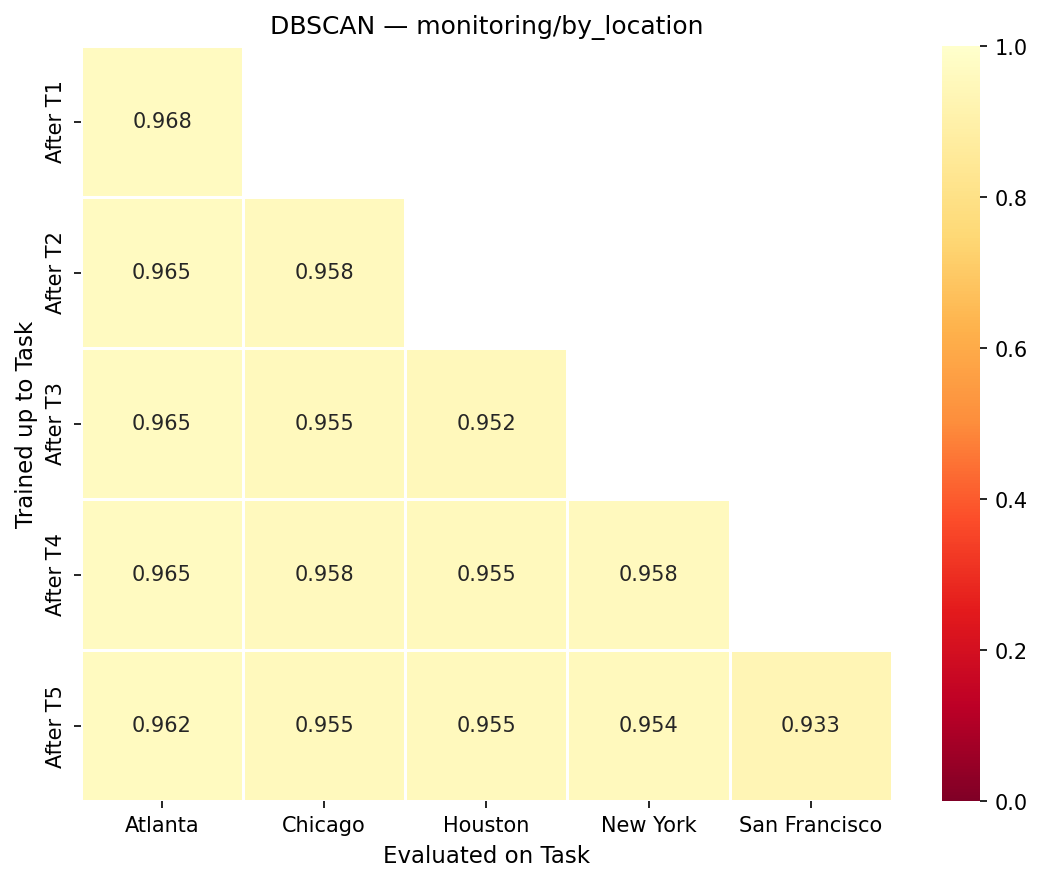

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# AF = 0 — cl_strategy=refit : core points recalculés à chaque tâche

fig = plot_accuracy_matrix(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_location",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_location/forgetting_curve.png


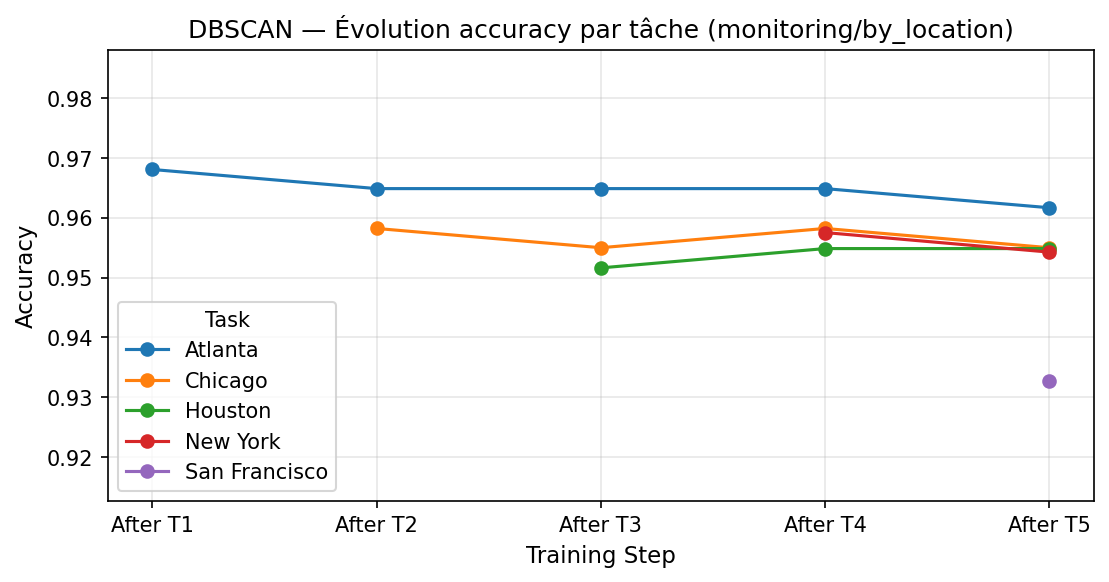

In [4]:
# Section 4 — Courbe d'oubli par tâche

fig = plot_forgetting_curve(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_location)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + scores_dict)
# Reproduit la config exp_023 : seed=42, eps=0.5, min_samples=5, anomaly_percentile=95
# Sur 5 locations : Atlanta → Chicago → Houston → New York → San Francisco

preds_dict        = {}  # (i, j) → (y_true, y_pred_binary)
scores_dict       = {}  # (i, j) → anomaly scores
X_tests_raw       = []
y_tests_raw       = []
saved_core_points = {}  # task_id → core points

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders_by_location
    from src.models.unsupervised.dbscan_detector import DBSCANDetector
    from src.utils.reproducibility import set_seed

    set_seed(42)

    full_config = yaml.safe_load(CONFIG_PATH.read_text())
    dbscan_cfg  = full_config["dbscan"]

    tasks = get_cl_dataloaders_by_location(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=256,
        seed=42,
        location_order=TASK_NAMES,
    )

    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    detector = DBSCANDetector(dbscan_cfg)

    for i, task in enumerate(tasks):
        domain = task.get("domain", TASK_NAMES[i])
        print(f"\n--- Tâche {i + 1}/{len(TASK_NAMES)} : {domain} ---")

        X_train = np.concatenate([b[0].numpy() for b in task["train_loader"]])
        detector.fit_task(X_train, task_id=i)
        saved_core_points[i] = detector.core_points_.copy()

        for j in range(i + 1):
            scores = detector.anomaly_score(X_tests_raw[j])
            y_pred = detector.predict(X_tests_raw[j]).astype(float)
            preds_dict[(i, j)]  = (y_tests_raw[j], y_pred)
            scores_dict[(i, j)] = scores
            acc = (y_tests_raw[j] == y_pred).mean()
            print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — preds_dict synthétique depuis acc_matrix/AUROC."))

    T = len(TASK_NAMES)
    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    for i in range(T):
        for j in range(i + 1):
            noise = rng.normal(0, 0.08, N_SYNTH)
            scores_synth = np.where(y_synth == 1, 0.70 + noise, 0.25 + noise).clip(0, 1)
            threshold = np.percentile(scores_synth[:N_SYNTH // 2], 95)
            y_pred_synth = (scores_synth > threshold).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_synth)
            scores_dict[(i, j)] = scores_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé)")

✅ Seed fixé à 42
✅ Seed fixé à 42

--- Tâche 1/5 : Atlanta ---
  [DBSCAN] Tâche 0 — eps=0.5, min_samples=5, n_core=688, n_noise=409/1251, RAM estimée=11008 B
  [DBSCAN] Seuil calculé sur Task 0 : 2.9597 (percentile 95)
  preds_dict[(0,0)] → N=313, acc=0.9681

--- Tâche 2/5 : Chicago ---
  [DBSCAN] Tâche 1 — eps=0.5, min_samples=5, n_core=697, n_noise=368/1242, RAM estimée=11152 B
  preds_dict[(1,0)] → N=313, acc=0.9649
  preds_dict[(1,1)] → N=311, acc=0.9582

--- Tâche 3/5 : Houston ---
  [DBSCAN] Tâche 2 — eps=0.5, min_samples=5, n_core=697, n_noise=389/1238, RAM estimée=11152 B
  preds_dict[(2,0)] → N=313, acc=0.9649
  preds_dict[(2,1)] → N=311, acc=0.9550
  preds_dict[(2,2)] → N=310, acc=0.9516

--- Tâche 4/5 : New York ---
  [DBSCAN] Tâche 3 — eps=0.5, min_samples=5, n_core=677, n_noise=372/1220, RAM estimée=10832 B
  preds_dict[(3,0)] → N=313, acc=0.9649
  preds_dict[(3,1)] → N=311, acc=0.9582
  preds_dict[(3,2)] → N=310, acc=0.9548
  preds_dict[(3,3)] → N=306, acc=0.9575

--- Tâc

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_location/confusion_matrix_grid.png


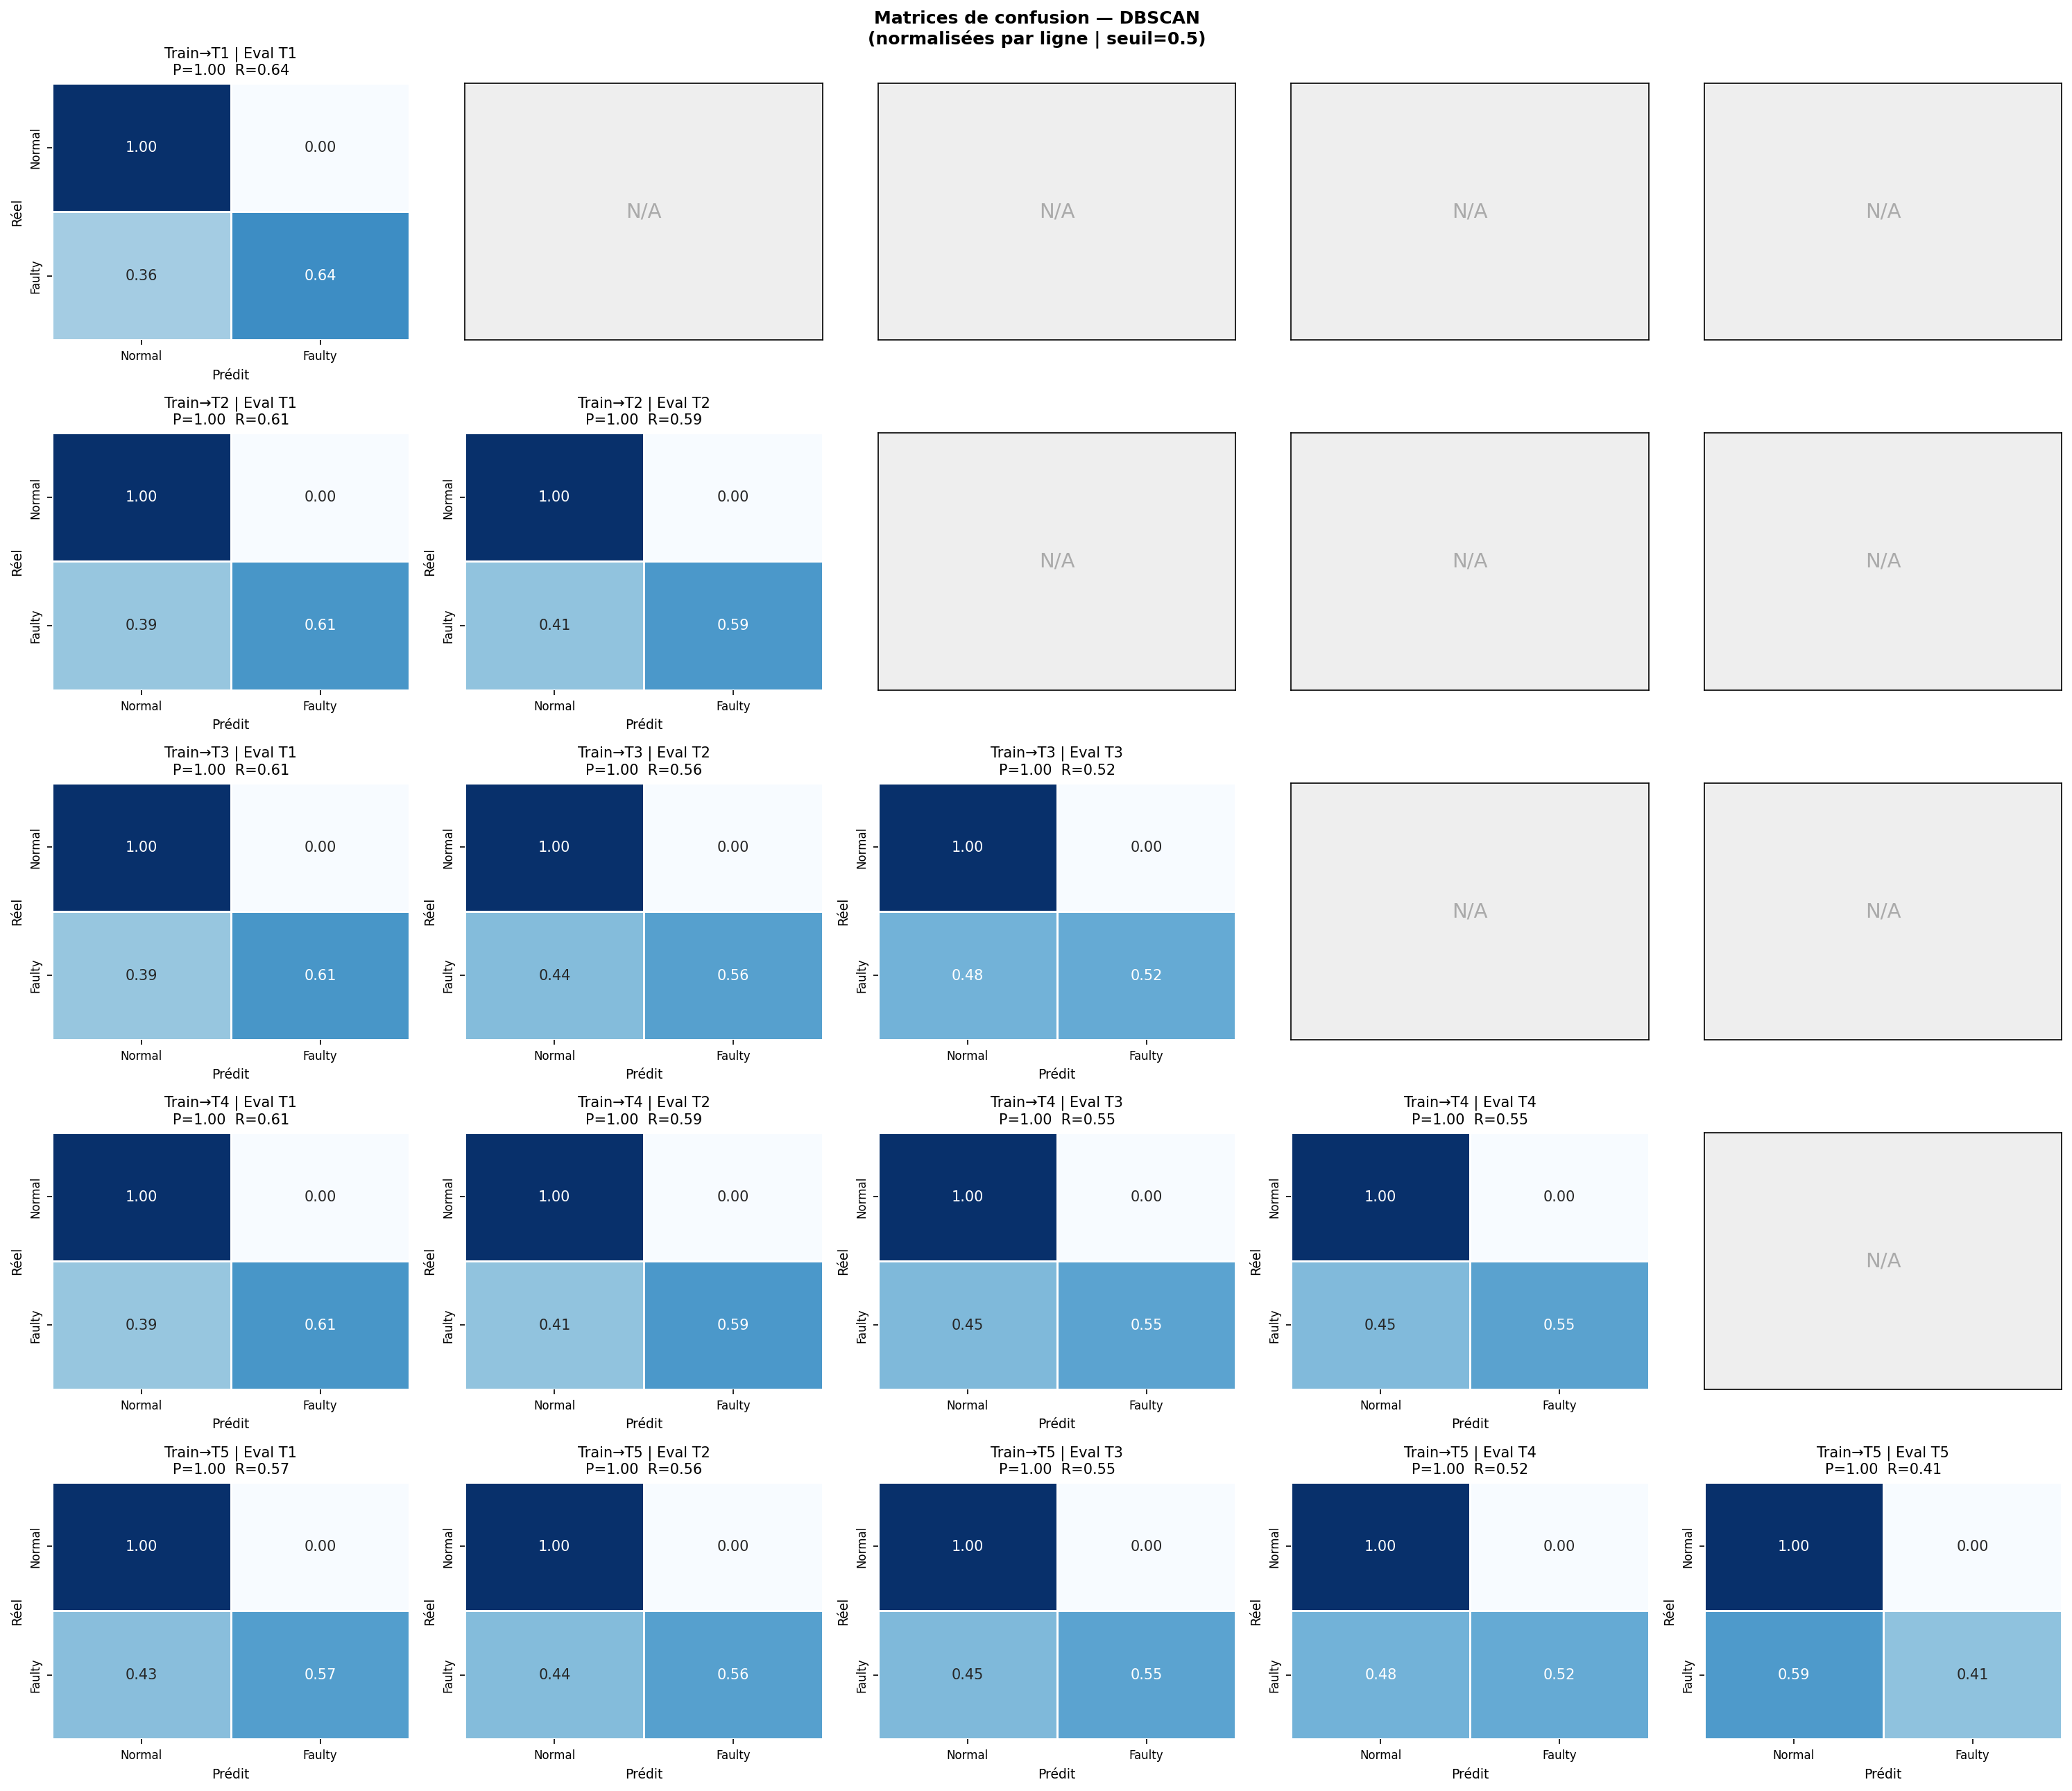

In [6]:
# Section 6 — Matrices de confusion par tâche (grille 5×5)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_location/auroc_curve.png


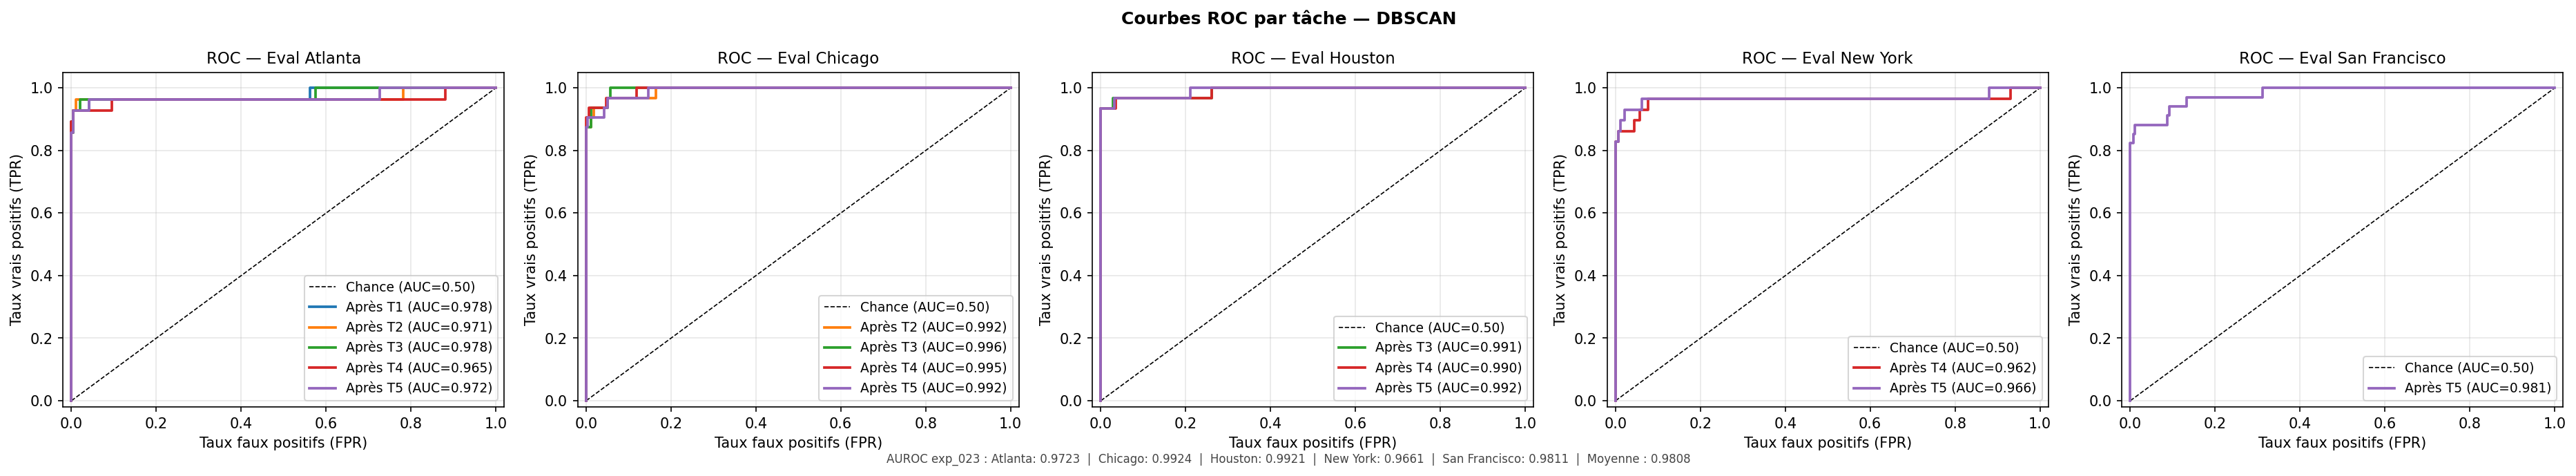

In [7]:
# Section 7 — Courbes AUROC par tâche (détection d'anomalie)
# La distance DBSCAN aux core points est un score continu → ROC bien définie
# AUROC attendu ≈ 0.9808 (moyenne des 5 tâches)

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=scores_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

if auroc_per_task:
    auroc_str = "  |  ".join(
        f"{TASK_NAMES[j]}: {auroc_per_task[j]:.4f}" for j in range(len(auroc_per_task))
    )
    fig.text(
        0.5, 0.01,
        f"AUROC exp_023 : {auroc_str}  |  Moyenne : {auroc_avg:.4f}",
        ha="center", fontsize=8, color="#444444",
    )

save_figure(fig, FIGURES_DIR / "auroc_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "auroc_curve.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_location/feature_space_pca.png


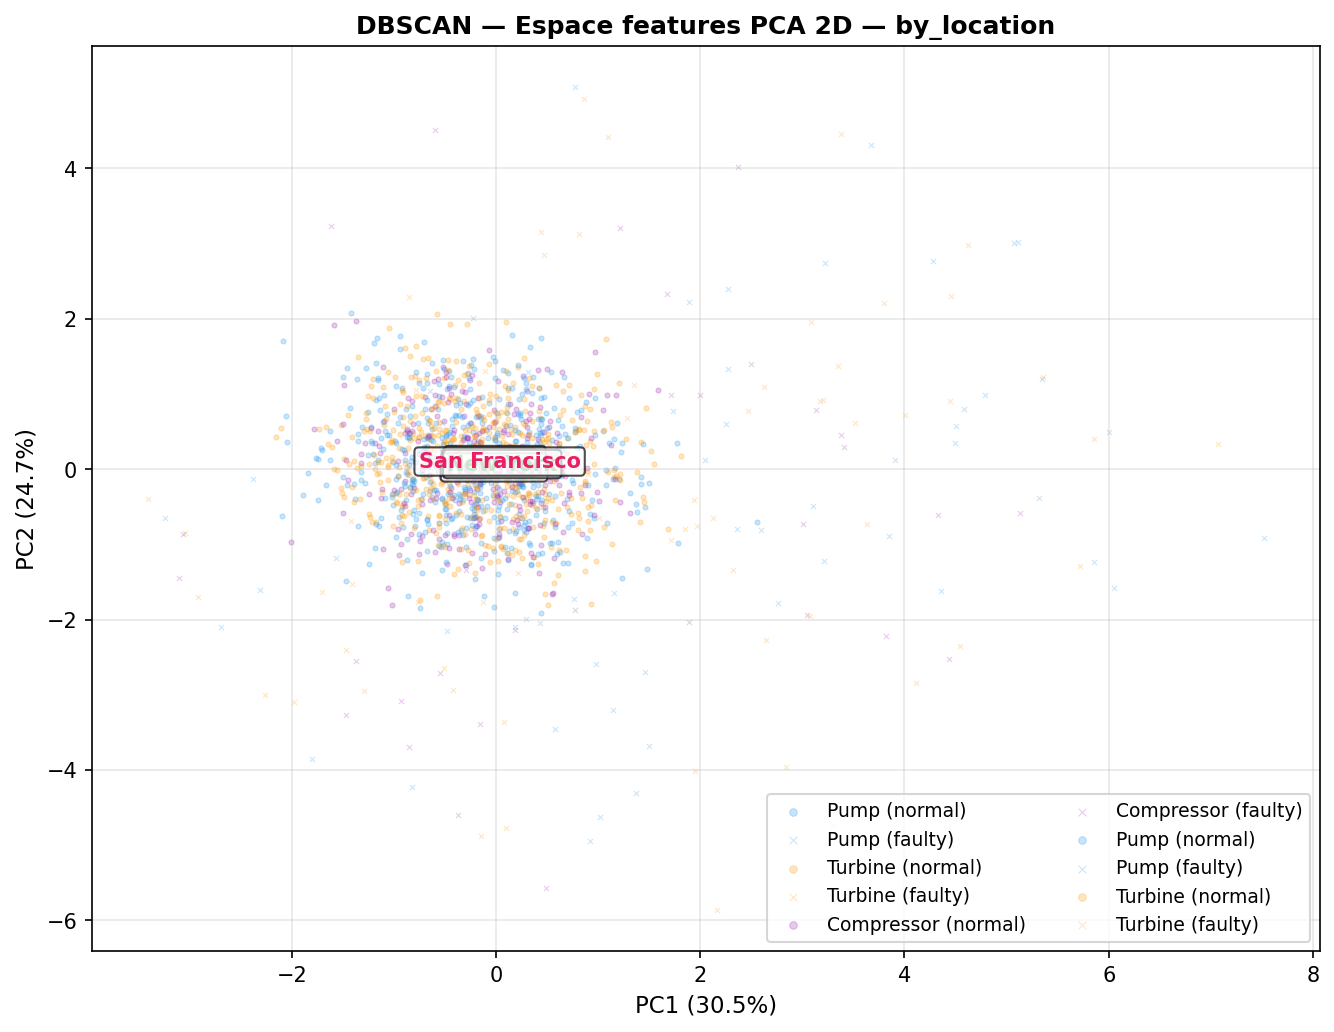

In [8]:
# Section 8 — Espace des features (PCA 2D)
# Visualise la distribution des 5 locations dans l'espace PCA 2D

if DATA_AVAILABLE and len(X_tests_raw) == len(TASK_NAMES):
    X_all      = np.concatenate(X_tests_raw, axis=0)
    y_all      = np.concatenate(y_tests_raw, axis=0)
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(len(TASK_NAMES))
    ])

    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_location",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0", "#4CAF50", "#E91E63"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=10,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    plt.close(fig)
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown("> ⚠️ **Section 8 ignorée** — données non disponibles."))
    print("[SKIP] feature_space_pca.png")

In [9]:
# Section 9 — Tableau récapitulatif + Discussion RAM (Gap 2)

ram_ko = ram_b / 1024
status_ram = "✅" if within_budget else "⚠️"

display(Markdown("### Résultats finaux — DBSCAN — monitoring/by_location (exp_023)"))

recap_table = f"""
| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_core×d |
|--------|------|------|-----|---------|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {auroc_avg:.4f} | {ram_ko:.2f} Ko {status_ram} | {lat:.5f} ms | {n_params} |
"""
display(Markdown(recap_table))

display(Markdown(f"""### Discussion — Contrainte embarquée (Gap 2 — comparaison by_equipment vs. by_location)

| Scénario | RAM DBSCAN | Status STM32N6 |
|----------|-----------|----------------|
| by_equipment (exp_008) | 71.9 Ko | ❌ FIXME(gap2) |
| **by_location (exp_023)** | **{ram_ko:.1f} Ko** | **{status_ram} {'Dans budget' if within_budget else 'Hors budget'}** |

**Pourquoi cette différence ?**  
Le scénario by_location présente une densité de données différente par ville : les distributions  
géographiques sont plus séparées, ce qui réduit le nombre de core points DBSCAN par tâche.  
Ainsi n_core_points × d = {n_params} contre 5 412 en by_equipment.

**Implication pour le Gap 2** :  
- DBSCAN est déployable sur STM32N6 dans le contexte géographique ({'✅' if within_budget else '❌'}).  
- La contrainte 64 Ko est sensible au nombre de points denses dans les données d'entrainement.  
- Un buffer borné de core points (top-N) reste recommandé pour garantir la contrainte en production.

`TODO(fred)` : En contexte Edge Spectrum, les données industrielles ressemblent-elles
au scénario by_equipment (type d'équipement) ou by_location (site géographique) ?
"""))

print("=" * 60)
print("  Critères d'acceptation (S7-12)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "auroc_curve.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9517) < 0.01 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9517)")
print(f"  [{'OK' if abs(af - 0.0032) < 0.005 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0032)")
print(f"  [{'OK' if abs(bwt - (-0.0024)) < 0.005 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ -0.0024)")
print(f"  [{'OK' if abs(auroc_avg - 0.9808) < 0.005 else 'WARN'}] AUROC  = {auroc_avg:.4f} (attendu ≈ 0.9808)")
print(f"  [{'OK' if within_budget else 'NOTE (Gap2)'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko) {status_ram}")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — DBSCAN — monitoring/by_location (exp_023)


| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_core×d |
|--------|------|------|-----|---------|-------|-----------|----------|
| DBSCAN | 0.9517 | 0.0032 | -0.0024 | 0.9808 | 40.53 Ko ✅ | 0.22764 ms | 2476 |


### Discussion — Contrainte embarquée (Gap 2 — comparaison by_equipment vs. by_location)

| Scénario | RAM DBSCAN | Status STM32N6 |
|----------|-----------|----------------|
| by_equipment (exp_008) | 71.9 Ko | ❌ FIXME(gap2) |
| **by_location (exp_023)** | **40.5 Ko** | **✅ Dans budget** |

**Pourquoi cette différence ?**  
Le scénario by_location présente une densité de données différente par ville : les distributions  
géographiques sont plus séparées, ce qui réduit le nombre de core points DBSCAN par tâche.  
Ainsi n_core_points × d = 2476 contre 5 412 en by_equipment.

**Implication pour le Gap 2** :  
- DBSCAN est déployable sur STM32N6 dans le contexte géographique (✅).  
- La contrainte 64 Ko est sensible au nombre de points denses dans les données d'entrainement.  
- Un buffer borné de core points (top-N) reste recommandé pour garantir la contrainte en production.

`TODO(fred)` : En contexte Edge Spectrum, les données industrielles ressemblent-elles
au scénario by_equipment (type d'équipement) ou by_location (site géographique) ?


  Critères d'acceptation (S7-12)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] auroc_curve.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.9517  (attendu ≈ 0.9517)
  [OK] AF     = 0.0032  (attendu ≈ 0.0032)
  [OK] BWT    = -0.0024 (attendu ≈ -0.0024)
  [OK] AUROC  = 0.9808 (attendu ≈ 0.9808)
  [OK] RAM    = 40.53 Ko (contrainte ≤ 64 Ko) ✅
  [OK] Latence= 0.22764 ms (contrainte ≤ 100 ms)
